## 1. Environment Setup & Data Loading

In [1]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
data = pd.read_csv(r"gym_members_exercise_tracking.csv")
data.head()

,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type,Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,1.69,1313,Yoga,4,3,30.20
1,46,Female,74.9,1.53,1.30,883,HIIT,4,2,32.00
2,32,Female,68.1,1.66,1.11,677,Cardio,4,2,24.71
3,25,Male,53.2,1.70,0.59,532,Strength,3,1,18.41
4,38,Male,46.1,1.79,0.64,556,Strength,3,1,14.39


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Dataset Dimensions
data.shape

(973, 10)

In [4]:
# Data Types and Summary
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Session_Duration (hours)       973 non-null    float64
 5   Calories_Burned                973 non-null    int64  
 6   Workout_Type                   973 non-null    object 
 7   Workout_Frequency (days/week)  973 non-null    int64  
 8   Experience_Level               973 non-null    int64  
 9   BMI                            973 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 76.1+ KB


In [5]:
# Descriptive Statistics
data.describe(include='all')

,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type,Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973,973.000000,973.00000,973.000000,973.000000,973,973.000000,973.000000,973.000000
unique,NaN,2,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,Strength,NaN,NaN,NaN
freq,NaN,511,NaN,NaN,NaN,NaN,258,NaN,NaN,NaN
mean,38.683453,NaN,73.854676,1.72258,1.256423,905.422405,NaN,3.321686,1.809866,24.912127
std,12.180928,NaN,21.207500,0.12772,0.343033,272.641516,NaN,0.913047,0.739693,6.660879
min,18.000000,NaN,40.000000,1.50000,0.500000,303.000000,NaN,2.000000,1.000000,12.320000
25%,28.000000,NaN,58.100000,1.62000,1.040000,720.000000,NaN,3.000000,1.000000,20.110000
50%,40.000000,NaN,70.000000,1.71000,1.260000,893.000000,NaN,3.000000,2.000000,24.160000
75%,49.000000,NaN,86.000000,1.80000,1.460000,1076.000000,NaN,4.000000,2.000000,28.560000


## 3. Data Preprocessing & Cleaning

In [6]:
# Checking for Missing Values
data.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [7]:
# Removing Duplicate Records
data.drop_duplicates(inplace=True)

In [8]:
data = data.drop('Workout_Type', axis=1)

In [9]:
data.head()

,Age,Gender,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,1.69,1313,4,3,30.20
1,46,Female,74.9,1.53,1.30,883,4,2,32.00
2,32,Female,68.1,1.66,1.11,677,4,2,24.71
3,25,Male,53.2,1.70,0.59,532,3,1,18.41
4,38,Male,46.1,1.79,0.64,556,3,1,14.39


In [10]:
data.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)',
       'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

## 4. Visualizing Data Relationships

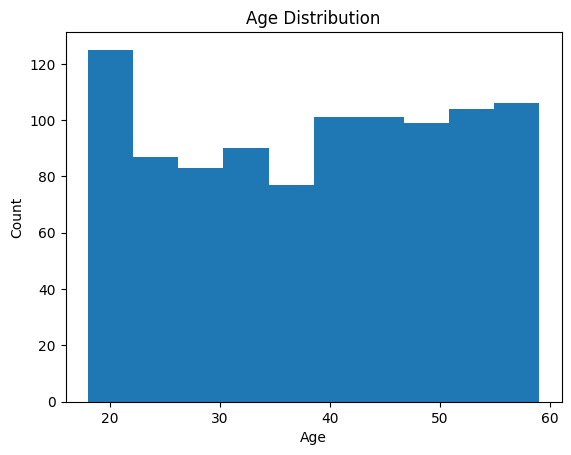

In [11]:
plt.hist(data["Age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Distribution of Target Variable: Calories Burned

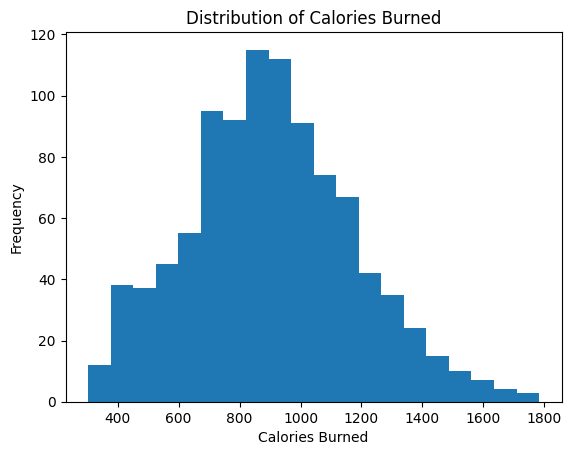

In [12]:
plt.hist(data["Calories_Burned"], bins=20)
plt.title("Distribution of Calories Burned")
plt.xlabel("Calories Burned")
plt.ylabel("Frequency")
plt.show()

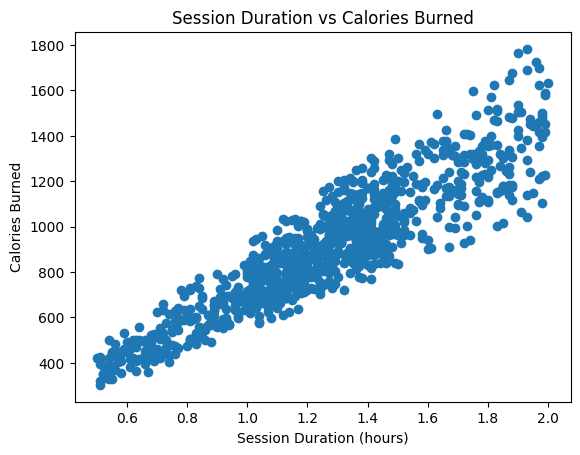

In [13]:
plt.scatter(data["Session_Duration (hours)"], data["Calories_Burned"])
plt.title("Session Duration vs Calories Burned")
plt.xlabel("Session Duration (hours)")
plt.ylabel("Calories Burned")
plt.show()

## 5. Feature Encoding & Model Building

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data["Gender"] = le.fit_transform(data["Gender"])

In [15]:
data['Gender'].value_counts()

Gender
1    511
0    462
Name: count, dtype: int64

In [16]:
X = data.drop('Calories_Burned', axis=1)
y = data['Calories_Burned']

In [17]:
print(X.shape)
print(y.shape)

(973, 8)
(973,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(778, 8)
(195, 8)
(778,)
(195,)


## 6. Model Evaluation and Final Results

### a. Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

pred_lr = lr.predict(X_test)

print("Model Evaluation Results\n")

print("Linear Regression R2 Score:", r2_score(y_test, pred_lr))

print("Linear Regression Mean Absolute Error:", mean_absolute_error(y_test, pred_lr))

Model Evaluation Results

Linear Regression R2 Score: 0.8751957214790362
Linear Regression Mean Absolute Error: 83.08404841584866


### b. Decision Tree

In [22]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [23]:
pred_dt = dt.predict(X_test)

print("Model Evaluation Results\n")

print("Decision Tree R2 Score:", r2_score(y_test, pred_dt))

print("Decision Tree Mean Absolute Error:", mean_absolute_error(y_test, pred_dt))

Model Evaluation Results

Decision Tree R2 Score: 0.7497658576286523
Decision Tree Mean Absolute Error: 111.06153846153846


### c. Random Forest

In [24]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [25]:
pred_rf = rf.predict(X_test)

print("Model Evaluation Results\n")

print("Random Forest R2 Score:", r2_score(y_test, pred_rf))

print("Random Forest MAE:", mean_absolute_error(y_test, pred_rf))

Model Evaluation Results

Random Forest R2 Score: 0.8617451756221461
Random Forest MAE: 86.4345641025641


## Actual vs Predicted Calories Burned (Model Performance)

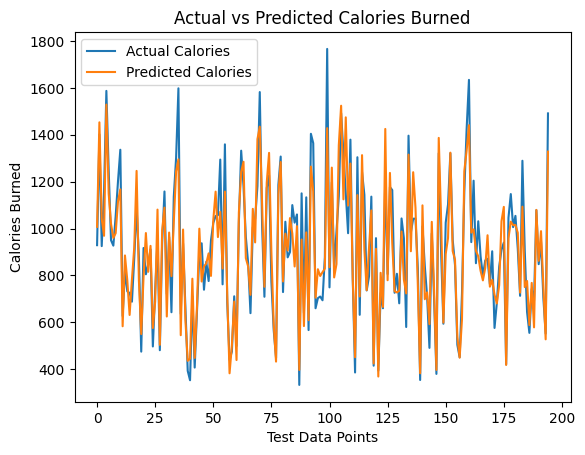

In [26]:
plt.plot(y_test.values, label="Actual Calories")
plt.plot(pred_rf, label="Predicted Calories")

plt.title("Actual vs Predicted Calories Burned")
plt.xlabel("Test Data Points")
plt.ylabel("Calories Burned")

plt.legend()

plt.show()

In [31]:
def recommend_workout(text):
    text = text.lower()
    
    if "fat" in text or "weight loss" in text:
        return "Cardio + HIIT"
    
    elif "muscle" in text or "gain" in text:
        return "Strength Training"
    
    elif "flexibility" in text or "stress" in text:
        return "Yoga"
    
    elif "beginner" in text:
        return "Light Cardio"
    
    else:
        return "General Fitness"

## 7. Model Deployment 

In [27]:
!pip install gradio

In [52]:
import numpy as np
import pickle

model = pickle.load(open("model.pkl","rb"))

pickle.dump(rf, open("model.pkl","wb"))

array([724.72])

In [44]:
def predict_calories(age, gender, weight, height, duration, frequency, experience, bmi, goal):

    features = np.array([[age, gender, weight, height, duration, frequency, experience, bmi]])
    
    prediction = model.predict(features)
    
    workout = recommend_workout(goal)
    
    return prediction[0], workout

In [46]:
import gradio as gr

interface = gr.Interface(
    fn=predict_calories,
    
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Gender (0 = Female, 1 = Male)"),
        gr.Number(label="Weight (kg)"),
        gr.Number(label="Height (m)"),
        gr.Number(label="Session Duration (hours)"),
        gr.Number(label="Workout Frequency (days/week)"),
        gr.Number(label="Experience Level"),
        gr.Number(label="BMI"),
        gr.Textbox(label="Enter your fitness goal")
    ],
    
    outputs=[
        gr.Number(label="Predicted Calories Burned"),
        gr.Textbox(label="Recommended Workout")
    ],
    
    title="Gym AI Fitness Assistant",
    
    description="Predict calories burned and get AI-based workout recommendation"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.
